# 🎭 Face Mask Detection System
**Stack:** OpenCV + TensorFlow/Keras (MobileNetV2)  
**No external API required** — fully local inference.

### Pipeline
1. Install dependencies
2. Capture training images from webcam
3. Train a MobileNetV2 model
4. Visualise training results
5. Score a single static image
6. Real-time webcam detection


In [1]:
# Cell 1 — Install required packages (run once)
import subprocess, sys

packages = [
    'opencv-python',
    'tensorflow',
    'numpy',
    'matplotlib',
    'scikit-learn',
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + packages)
print('All packages installed.')


All packages installed.


In [2]:
# Cell 2 — Create image directories
import os

os.makedirs('./Images/Mask',    exist_ok=True)
os.makedirs('./Images/No Mask', exist_ok=True)
print('Directories ready:')
print('  ./Images/Mask')
print('  ./Images/No Mask')


Directories ready:
  ./Images/Mask
  ./Images/No Mask


In [3]:
import cv2, uuid

cap = cv2.VideoCapture(0)            # 0 = default webcam

if not cap.isOpened():
    raise RuntimeError(
        'Could not open webcam. '
        'Check that no other app is using it and try camera index 1 if index 0 fails.'
    )

w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'Camera opened: {w}x{h}')
print('Press  Q  to stop capturing.')

count = 0
while True:
    ret, frame = cap.read()
    if not ret:                        # FIX: graceful frame-grab failure
        print('Warning: failed to grab frame — stopping.')
        break

    imgname = f'./Images/No Mask/{uuid.uuid1()}.jpg'
    cv2.imwrite(imgname, frame)
    count += 1

    cv2.putText(frame, f'No Mask | Saved: {count}', (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    cv2.imshow('Capturing — No Mask  (press Q to stop)', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()              # FIX: module-level call, not cap.destroyAllWindows()
print(f'Done. Saved {count} No-Mask images.')


Camera opened: 640x480
Press  Q  to stop capturing.
Done. Saved 160 No-Mask images.


In [4]:
# Cell 4 — Capture MASK images  (put your mask on first!)
import cv2, uuid

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError('Could not open webcam.')

print('Press  Q  to stop capturing.')

count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        print('Warning: failed to grab frame — stopping.')
        break

    imgname = f'./Images/Mask/{uuid.uuid1()}.jpg'
    cv2.imwrite(imgname, frame)
    count += 1

    cv2.putText(frame, f'Mask | Saved: {count}', (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    cv2.imshow('Capturing — Mask  (press Q to stop)', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print(f'Done. Saved {count} Mask images.')


Press  Q  to stop capturing.
Done. Saved 86 Mask images.


In [5]:
# Cell 5 — Load images and pre-process for MobileNetV2
import numpy as np
import os, cv2
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array, load_img

print('TensorFlow version:', tf.__version__)

IMG_SIZE   = 224
CATEGORIES = {'Mask': 1, 'No Mask': 0}   # label encoding

data, labels = [], []

for category, label in CATEGORIES.items():
    folder = f'./Images/{category}'
    if not os.path.exists(folder):
        print(f'WARNING: folder not found — {folder}  (skipping)')
        continue
    files = [f for f in os.listdir(folder)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f'Loading {len(files):>4} images from "{category}" ...')
    for fname in files:
        fpath = os.path.join(folder, fname)
        try:
            img = load_img(fpath, target_size=(IMG_SIZE, IMG_SIZE))
            img = img_to_array(img)
            img = preprocess_input(img)  # scales to [-1, 1] for MobileNetV2
            data.append(img)
            labels.append(label)
        except Exception as e:
            print(f'  Skipping corrupt file {fname}: {e}')

data   = np.array(data,   dtype='float32')
labels = np.array(labels, dtype='int')
print(f'\nTotal images loaded: {len(data)}')
print(f'  Mask   : {(labels == 1).sum()}')
print(f'  No Mask: {(labels == 0).sum()}')

if len(data) < 10:
    raise ValueError(
        'Too few images to train. Capture at least 50 images per class '
        '(100+ recommended) and re-run Cells 3 & 4.'
    )


TensorFlow version: 2.21.0
Loading  131 images from "Mask" ...
Loading  343 images from "No Mask" ...

Total images loaded: 474
  Mask   : 131
  No Mask: 343


In [6]:
# Cell 6 — Train / test split
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

labels_cat = to_categorical(labels, num_classes=2)

X_train, X_test, y_train, y_test = train_test_split(
    data, labels_cat,
    test_size=0.20,
    stratify=labels_cat,
    random_state=42
)
print(f'Train samples : {len(X_train)}')
print(f'Test  samples : {len(X_test)}')


Train samples : 379
Test  samples : 95


In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

INIT_LR = 1e-4
EPOCHS  = 20
BS      = 32

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_tensor=Input(shape=(224, 224, 3))
)
base_model.trainable = False   # freeze pre-trained weights

head = base_model.output
head = AveragePooling2D(pool_size=(7, 7))(head)
head = Flatten()(head)
head = Dense(128, activation='relu')(head)
head = Dropout(0.5)(head)
head = Dense(2,   activation='softmax')(head)

model = Model(inputs=base_model.input, outputs=head)

model.compile(
    optimizer=Adam(learning_rate=INIT_LR),
    loss='categorical_crossentropy',   # FIX: was 'binary_crossentropy'
    metrics=['accuracy']
)

print(f'Trainable params: {sum(p.numpy().size for p in model.trainable_weights):,}')
print('Model ready.')


C:\Users\DELL\AppData\Local\Temp\ipykernel_22748\1362310323.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Trainable params: 164,226
Model ready.


In [8]:
# Cell 8 — Train the model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('mask_detector_best.h5', save_best_only=True, monitor='val_loss', verbose=0),
]

history = model.fit(
    X_train, y_train,
    batch_size=BS,
    epochs=EPOCHS,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

model.save('mask_detector.h5')
print('Model saved  →  mask_detector.h5')
print('Best model   →  mask_detector_best.h5')


Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6066 - loss: 0.7774

12/12 ━━━━━━━━━━━━━━━━━━━━ 121s 5s/step - accuracy: 0.6332 - loss: 0.7359 - val_accuracy: 0.7263 - val_loss: 0.5696
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6193 - loss: 0.6954

12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6702 - loss: 0.6347 - val_accuracy: 0.7263 - val_loss: 0.5297
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6958 - loss: 0.5821

12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7150 - loss: 0.5587 - val_accuracy: 0.8105 - val_loss: 0.4881
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7350 - loss: 0.5365

12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.7546 - loss: 0.5143 - val_accuracy: 0.8105 - val_loss: 0.4636
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 947ms/step - accuracy: 0.8035 - loss: 0.4555

...

12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9499 - loss: 0.2157 - val_accuracy: 0.9053 - val_loss: 0.2365
Epoch 18/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9371 - loss: 0.1998

12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9472 - loss: 0.2011 - val_accuracy: 0.9053 - val_loss: 0.2207
Epoch 19/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9565 - loss: 0.1858

12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9578 - loss: 0.1916 - val_accuracy: 0.9053 - val_loss: 0.2198
Epoch 20/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 968ms/step - accuracy: 0.9655 - loss: 0.1768

12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9763 - loss: 0.1627 - val_accuracy: 0.9053 - val_loss: 0.2055
Restoring model weights from the end of the best epoch: 20.


Model saved  →  mask_detector.h5
Best model   →  mask_detector_best.h5


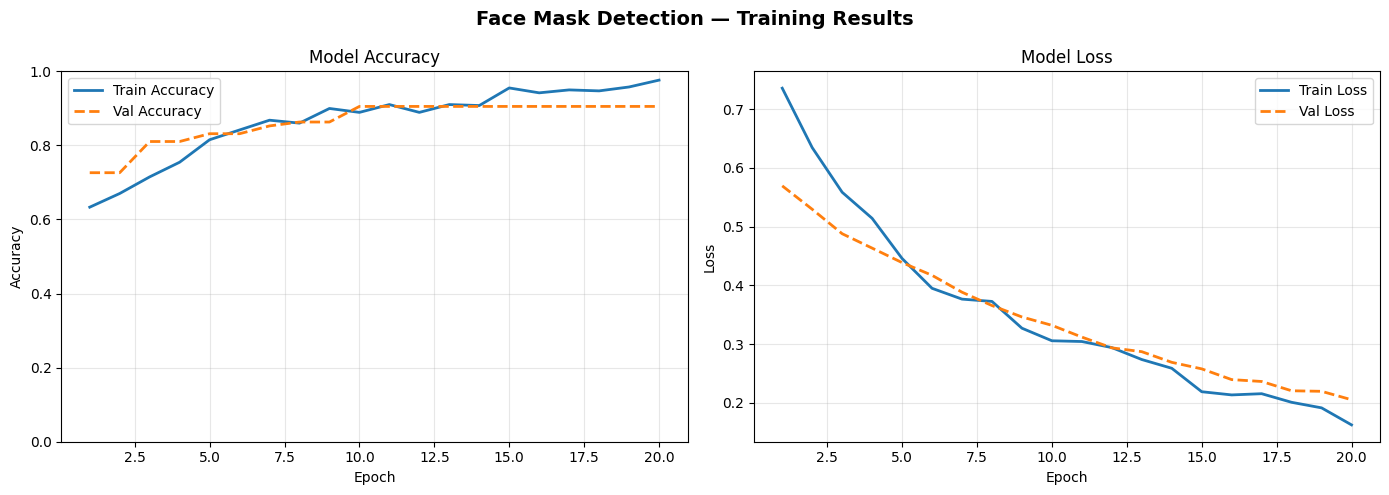

Saved → training_curves.png


In [9]:
# Cell 9 — Visualise training curves
# FIX: len(history.history['accuracy']) used for x-axis so it always
#      matches actual epochs trained (EarlyStopping may stop early).
from matplotlib import pyplot as plt

actual_epochs = len(history.history['accuracy'])
epochs_range  = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Face Mask Detection — Training Results', fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(epochs_range, history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy',   linewidth=2, linestyle='--')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(epochs_range, history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(epochs_range, history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → training_curves.png')


Testing on: ./Images/Mask\43789025-5710-11f1-b8c6-1065305dd8ca.jpg
Face at (268,236) → No Mask  (93.3%)


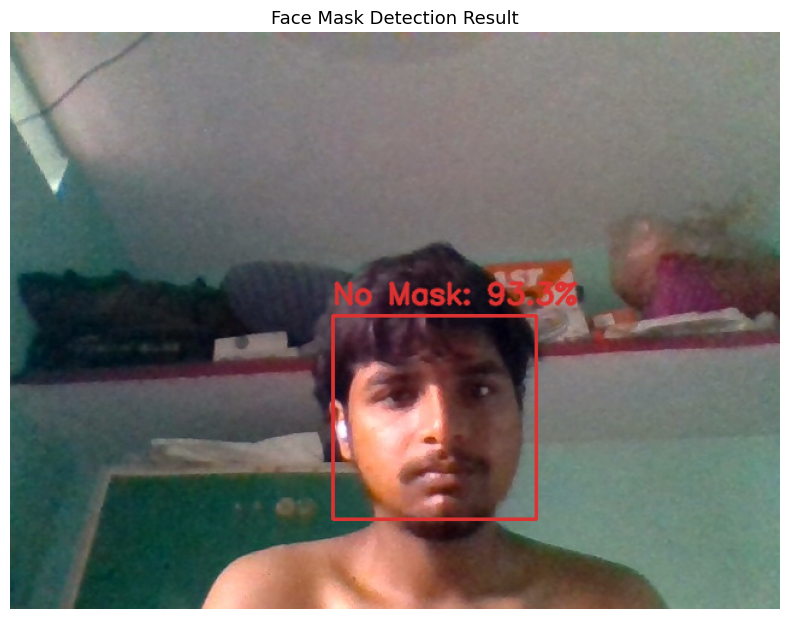

Saved → detection_result.png


In [10]:
# Cell 10 — Score a single static image
# FIX (Cell 3 error): path had extra quotes inside the string — removed them.
# FIX: path uses raw string (r'...') to handle Windows backslashes correctly.
# FIX: added os.path.exists() check so the error is clear, not a cryptic NoneType crash.
import cv2, os
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from matplotlib import pyplot as plt

model        = load_model('mask_detector.h5')
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

LABELS = {0: 'No Mask', 1: 'Mask'}
COLORS = {0: (220, 50,  50),   # Red-ish  — No Mask
          1: (50,  200, 50)}   # Green    — Mask

# ── Change this path to point to your test image ──────────────────────────
# Use a raw string (r'...') on Windows to avoid backslash escapes.
# Example Windows path:
#   path = r'C:\Users\YourName\Desktop\test.jpg'
# Example relative path (if image is in same folder as notebook):
#   path = './test.jpg'
# ---- UPDATE THIS PATH to any test image (mask or no-mask) ----
import glob
_candidates = (glob.glob("./Images/Mask/*.jpg") + glob.glob("./Images/Mask/*.png") +
               glob.glob("./Images/No Mask/*.jpg") + glob.glob("./Images/No Mask/*.png"))
if not _candidates:
    raise FileNotFoundError("No images found in ./Images/. Capture images in Cells 3 & 4 first.")
path = _candidates[0]   # auto-picks first available image; change to a specific path if you like
print(f"Testing on: {path}")
# ---------------------------------------------------------------
# ──────────────────────────────────────────────────────────────────────────

if not os.path.exists(path):
    raise FileNotFoundError(
        f'Image not found: {path}\n'
        'Please update the `path` variable above with a valid image path.'
    )

img_bgr = cv2.imread(path)
if img_bgr is None:
    raise ValueError(f'cv2.imread could not read: {path}  — check the file is a valid image.')

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(60, 60)
)

if len(faces) == 0:
    print('No face detected in the image.  Try a clearer / closer-up photo.')
else:
    for (x, y, w, h) in faces:
        face_roi = img_rgb[y:y+h, x:x+w]
        face_roi = cv2.resize(face_roi, (224, 224))
        face_roi = img_to_array(face_roi)
        face_roi = preprocess_input(face_roi)
        face_roi = np.expand_dims(face_roi, axis=0)

        preds      = model.predict(face_roi, verbose=0)[0]  # shape: (2,)
        class_idx  = int(np.argmax(preds))
        label      = LABELS[class_idx]
        confidence = preds[class_idx] * 100
        color      = COLORS[class_idx]

        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), color, 2)
        text = f'{label}: {confidence:.1f}%'
        cv2.putText(img_rgb, text, (x, max(y - 10, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2, cv2.LINE_AA)

        print(f'Face at ({x},{y}) → {label}  ({confidence:.1f}%)')

plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Face Mask Detection Result', fontsize=13)
plt.tight_layout()
plt.savefig('detection_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → detection_result.png')


In [ ]:
import cv2, time, threading
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

# ── Config ─────────────────────────────────────────────────────────────────
CONFIDENCE_THRESHOLD = 0.60   # predictions below this show as 'Uncertain'
ALARM_COOLDOWN       = 2.0    # seconds between repeated alarm beeps

# Binary classification labels — clear and descriptive
LABELS = {0: 'NO MASK', 1: 'MASK'}
COLORS = {
    0: (0,   0, 255),   # BGR Red   — No Mask  ✗
    1: (0, 255,   0),   # BGR Green — Mask      ✓
    2: (0, 165, 255),   # BGR Orange — Uncertain
}
# ───────────────────────────────────────────────────────────────────────────

# ── Alarm Sound Setup ───────────────────────────────────────────────────────
try:
    import winsound
    def beep_alarm():
        for _ in range(3):
            winsound.Beep(1000, 300)
            time.sleep(0.1)
    SOUND_BACKEND = 'winsound'
except ImportError:
    import subprocess
    def beep_alarm():
        for _ in range(3):
            try:
                subprocess.run(['beep', '-f', '1000', '-l', '300'],
                               timeout=1, capture_output=True)
            except Exception:
                print('\a', end='', flush=True)
            time.sleep(0.1)
    SOUND_BACKEND = 'subprocess/bell'

print(f'Sound backend  : {SOUND_BACKEND}')

alarm_active = False

def trigger_alarm():
    global alarm_active
    alarm_active = True
    beep_alarm()
    time.sleep(ALARM_COOLDOWN)
    alarm_active = False
# ───────────────────────────────────────────────────────────────────────────

model = load_model('mask_detector.h5')
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError('Cannot open webcam.')

print('Real-time Face Mask Detection started.')
print('ALARM will beep when a person WITHOUT a mask is detected.')
print('Press  Q  to quit.')

prev_time = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        print('Frame grab failed — stopping.')
        break

    frame_h, frame_w = frame.shape[:2]

    # ── FPS ────────────────────────────────────────────────────────────────
    curr_time = time.time()
    fps       = 1.0 / max(curr_time - prev_time, 1e-9)
    prev_time = curr_time

    # ── Face detection ─────────────────────────────────────────────────────
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60)
    )

    no_mask_in_frame = False

    for (x, y, w, h) in faces:
        face_roi = frame[y:y+h, x:x+w]
        face_roi = cv2.cvtColor(face_roi, cv2.COLOR_BGR2RGB)
        face_roi = cv2.resize(face_roi, (224, 224))
        face_roi = img_to_array(face_roi)
        face_roi = preprocess_input(face_roi)
        face_roi = np.expand_dims(face_roi, axis=0)

        preds      = model.predict(face_roi, verbose=0)[0]
        class_idx  = int(np.argmax(preds))
        confidence = float(preds[class_idx])

        if confidence >= CONFIDENCE_THRESHOLD:
            label = LABELS[class_idx]      # 'MASK' or 'NO MASK'
            color = COLORS[class_idx]
            if class_idx == 0:
                no_mask_in_frame = True
        else:
            label = 'UNCERTAIN'
            color = COLORS[2]

        # ── Bounding box ───────────────────────────────────────────────────
        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 3)

        # ── Label badge with filled background ────────────────────────────
        badge_text = f'{label}  {confidence*100:.0f}%'
        (tw, th), _ = cv2.getTextSize(badge_text, cv2.FONT_HERSHEY_SIMPLEX, 0.75, 2)
        ty = max(y - th - 10, th + 6)
        cv2.rectangle(frame, (x, ty - th - 6), (x + tw + 8, ty + 4), color, -1)
        cv2.putText(frame, badge_text, (x + 4, ty),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2, cv2.LINE_AA)

        # ── Binary classification icon beside box ──────────────────────────
        icon = '✓ WITH MASK' if class_idx == 1 else '✗ WITHOUT MASK'
        icon_color = (0, 220, 0) if class_idx == 1 else (0, 0, 220)
        cv2.putText(frame, icon, (x, y + h + 28),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, icon_color, 2, cv2.LINE_AA)

    # ── Alarm trigger ──────────────────────────────────────────────────────
    if no_mask_in_frame and not alarm_active:
        threading.Thread(target=trigger_alarm, daemon=True).start()

    # ── NO MASK DETECTED — large full-width overlay ────────────────────────
    if no_mask_in_frame or alarm_active:
        # Semi-transparent dark red banner across bottom of frame
        overlay = frame.copy()
        banner_h = 70
        cv2.rectangle(overlay,
                      (0, frame_h - banner_h),
                      (frame_w, frame_h),
                      (0, 0, 180), -1)
        cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)

        # Flashing effect — show text every other half-second
        if int(time.time() * 2) % 2 == 0:
            msg = '⚠  NO MASK DETECTED  ⚠'
            (mw, mh), _ = cv2.getTextSize(msg, cv2.FONT_HERSHEY_DUPLEX, 1.1, 3)
            mx = (frame_w - mw) // 2
            my = frame_h - 18
            # Shadow for readability
            cv2.putText(frame, msg, (mx + 2, my + 2),
                        cv2.FONT_HERSHEY_DUPLEX, 1.1, (0, 0, 0), 3, cv2.LINE_AA)
            cv2.putText(frame, msg, (mx, my),
                        cv2.FONT_HERSHEY_DUPLEX, 1.1, (0, 80, 255), 3, cv2.LINE_AA)

    # ── HUD — top-left status ───────────────────────────────────────────────
    cv2.putText(frame, f'FPS: {fps:.1f}', (10, 28),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, (220, 220, 220), 2, cv2.LINE_AA)
    cv2.putText(frame, f'Faces: {len(faces)}', (10, 54),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, (220, 220, 220), 2, cv2.LINE_AA)

    # ── Status indicator — top right ───────────────────────────────────────
    status_text  = 'ALL MASKED ✓' if (len(faces) > 0 and not no_mask_in_frame) else                    ('NO MASK DETECTED ✗' if no_mask_in_frame else 'NO FACE DETECTED')
    status_color = (0, 200, 0)  if (len(faces) > 0 and not no_mask_in_frame) else                    ((0, 0, 255) if no_mask_in_frame else (180, 180, 180))
    (sw, _), _   = cv2.getTextSize(status_text, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
    cv2.putText(frame, status_text, (frame_w - sw - 10, 28),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, status_color, 2, cv2.LINE_AA)

    cv2.imshow('Face Mask Detection  —  Press Q to quit', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print('Detection stopped.')


Sound backend  : winsound


Real-time Face Mask Detection started.
ALARM will beep when a person WITHOUT a mask is detected.
Press  Q  to quit.
